# PQ-Map

In [1]:
import clip
import torch
import cv2
import numpy as np
from PIL import Image
from  matplotlib import pyplot as plt
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torchvision.transforms import InterpolationMode
BICUBIC = InterpolationMode.BICUBIC
from segment_anything import sam_model_registry, SamPredictor

device='cuda'
model, preprocess = clip.load("CS-ViT-B/16", device=device, jit=False)
model.eval()

CLIPSurgery(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
   

In [2]:
def load_embed(state_dict):
    ctx=state_dict['params']['prompt_learner.ctx']
    token_prefix=state_dict['params']['prompt_learner.token_prefix']
    token_suffix=state_dict['params']['prompt_learner.token_suffix']
    pos=torch.cat((state_dict['params']['prompt_learner.token_prefix'], state_dict['params']['prompt_learner.ctx'], state_dict['params']['prompt_learner.token_suffix']), 1).to(device)
    name_len=3
    half_n_ctx=8
    prefix_i = token_prefix[:, :, :]
    class_i = token_suffix[:, :name_len, :]
    suffix_i = token_suffix[:, name_len:, :]
    ctx_i_half1 = ctx[:, :half_n_ctx, :]
    ctx_i_half2 = ctx[:, half_n_ctx:, :]
    text_embed = torch.cat(
        [
            prefix_i,     # (1, 1, dim)
            ctx_i_half1,  # (1, n_ctx//2, dim)
            class_i,      # (1, name_len, dim)
            ctx_i_half2,  # (1, n_ctx//2, dim)
            suffix_i,     # (1, *, dim)
        ],
        dim=1,
    ).to(device).type(model.dtype)
    return text_embed

def encode_text(text_embed, pos):
    x = text_embed

    #x = x + model.positional_embedding.type(model.dtype)
    x = x + pos
    x = x.permute(1, 0, 2)  # NLD -> LND
    x = model.transformer(x)
    x = x.permute(1, 0, 2)  # LND -> NLD
    x = model.ln_final(x).type(model.dtype)

    # x.shape = [batch_size, n_ctx, transformer.width]
    # take features from the eot embedding (eot_token is the highest number in each sequence)
    x = x[torch.arange(x.shape[0]), torch.tensor([20, 20])] @ model.text_projection

    return x

def single_quality_map(image,text_embed,img_size):
    with torch.no_grad():
    # Extract image features
        image_features = model.encode_image(image)
        image_features = image_features / image_features.norm(dim=1, keepdim=True)

        # Prompt ensemble for text features with normalization
        text_features = encode_text(text_embed, pos_embed)

        # Similarity map from image tokens with min-max norm and resize, B,H,W,N
        features = image_features @ text_features.t()
        similarity_map = clip.get_similarity_map(features[:, 1:, :], img_size)

        feature_per=features[0][0].cpu().numpy()
        perceptual_score=np.exp(feature_per)[0]/np.sum(np.exp(feature_per))
        perceptual_map=similarity_map[0,:,:,0]
        return perceptual_map, perceptual_score

def perceptual_quality_map(pil_img, preprocess, multi=False, draw=True, bound1=1.0, bound2=0.6, bound3=0.8):
    #bound characterize importance of technical, rational, and natural quality
    
    image = preprocess(pil_img).unsqueeze(0).to(device)
    pm0, ps0 = single_quality_map(image,text_embed,pil_img.size)
    pm0 = pm0.cpu().numpy()
    if draw:
        cv2_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
        vis = (pm0 * 255).astype('uint8')
        vis = cv2.applyColorMap(vis, cv2.COLORMAP_JET)
        vis = cv2_img * 0.4 + vis * 0.6
        vis = cv2.cvtColor(vis.astype('uint8'), cv2.COLOR_BGR2RGB)
        plt.axis('off')
        plt.imshow(vis)
        plt.savefig('PQ-Map.png')
    
    if multi:
        ps1 = single_quality_map(image,text_embed_1,pil_img.size)[1]
        ps2 = single_quality_map(image,text_embed_2,pil_img.size)[1]
        ps3 = single_quality_map(image,text_embed_3,pil_img.size)[1]
        
        ### average perference value of AGIN database
        bound1=0.935*bound1
        bound2=0.892*bound2
        bound3=0.826*bound3
        
        # Normalize
        t=min(ps1/bound1,1) * min(ps2/bound1,1) * min(ps3/bound1,1)
        return pm0, ps0*t
    
    else:
        return pm0, ps0




#all_texts=["low quality", "high quality"]
#state_dict = torch.load("D:/SJTUMM/IQA-PyTorch-main/experiments/CLIPIQA_RN50_AGIN_embed_0/models/net_best.pth")
state_dict = torch.load("./embeding/PQ-overall.pth")
state_dict_1 = torch.load("./embeding/PQ-technical.pth")
state_dict_2 = torch.load("./embeding/PQ-rational.pth")
state_dict_3 = torch.load("./embeding/PQ-natural.pth")

text_embed = load_embed(state_dict)
text_embed_1 = load_embed(state_dict_1)
text_embed_2 = load_embed(state_dict_2)
text_embed_3 = load_embed(state_dict_3)   

pos_embed = model.positional_embedding.type(model.dtype)

This is only a visualization exmaple of perceptual map:


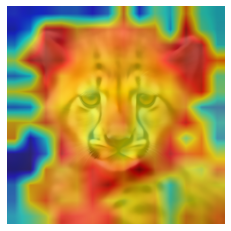

In [4]:
pil_img = Image.open("perceptual-example.jpg")
print('This is only a visualization exmaple of perceptual map:')
pm, ps = perceptual_quality_map(pil_img=pil_img, preprocess=preprocess, draw=True, multi=False)

In [6]:
pil_img = Image.open("alignment-example.jpg")
print('This is the image for refinement in following steps, you must run it.')
pm, ps = perceptual_quality_map(pil_img=pil_img, preprocess=preprocess, draw=False, multi=True)

This is the image for refinement in following steps, you must run it.


# AQ-Map

In [7]:
import spacy
from nltk import Tree
import string
from nltk.corpus import stopwords

def partition(sentence, noun_phrases):
    if len(noun_phrases) == 1 or len(noun_phrases) == 0:
        return [sentence] 
    parts = []
    cur_part_index = 0
    cur_find_begin_index = 0
    for phrase_idx, cur_noun_phrase in enumerate(noun_phrases):
        find_index = sentence.find(cur_noun_phrase, cur_find_begin_index)
        assert find_index != -1
        if phrase_idx == 0:
            cur_part_index = 0
            cur_find_begin_index = find_index + len(cur_noun_phrase)
        elif phrase_idx == len(noun_phrases) - 1:
            parts.append(sentence[cur_part_index:find_index].strip())
            cur_part_index = find_index
            parts.append(sentence[cur_part_index:].strip())
        else:
            parts.append(sentence[cur_part_index:find_index].strip())
            cur_part_index = find_index
            cur_find_begin_index = find_index + len(cur_noun_phrase)
    return parts

def remove_stopwords_and_punctuation(phrases):
    stop = set(stopwords.words('english')) 
    new_phrases = []
    for phrase in phrases:
        new_phrase= ' '.join([w for w in phrase.split(' ') if w not in stopwords.words('english') and w not in string.punctuation])
        new_phrases.append(new_phrase)
    return new_phrases

def to_nltk_tree(node):
    # print(node)
    # print(list(node.children))
    # print(node.pos_)
    if node.n_lefts + node.n_rights > 0:
        return Tree(node.orth_, [to_nltk_tree(child) for child in node.children])
    else:
        return node.orth_

def to_noun_tree(node):
    # print(node)
    # print(list(node.children))
    # print(node.pos_)
    # print(node.orth_)
    # print(list(node.ancestors))
    # if len(list(node.ancestors))>0:
    #     print(list(node.ancestors)[0])
    #     print(list(node.ancestors)[0].orth_)
    
    if node.pos_ == "NOUN" or node.pos_ == "PROPN":
        if node.n_lefts + node.n_rights > 0:
            return Tree(node.orth_, [to_noun_tree(child) for child in node.children])
        else:
            return node.orth_
    else:
        # return [to_noun_tree(child) for child in node.children]
        if node.n_lefts + node.n_rights > 0:
            if len(list(node.ancestors))>0:
                # return Tree(list(node.ancestors)[0].orth_, [to_noun_tree(child) for child in node.children])
                return Tree("None", [to_noun_tree(child) for child in node.children])
            else:
                return Tree(node.orth_, [to_noun_tree(child) for child in node.children])
        else:
            # return []   
            return None
        # return Tree([to_noun_tree(child) for child in node.children])
    
def get_phrase_level(sentence, phrases, nltk_tree):
    words = sentence.strip().split()
    # words_to_level = {}
    node_queue = [nltk_tree.root]
    words_to_level = {nltk_tree.root: 0}
    while node_queue:
        cur_node = node_queue[0]
        for child in list(cur_node.children):
            node_queue.append(child)
            words_to_level[child] =  words_to_level[cur_node] + 1
        node_queue = node_queue[1:]
    # print(words_to_level)
    return words_to_level

def get_token_to_pos_dictionary(doc):
    token_to_pos_dictionary = {}
    for token in doc:
        token_to_pos_dictionary[token.text] = token.pos_
    return token_to_pos_dictionary


def get_phrase_parent(sentence, phrases, filtered_phrases, nltk_tree, token_to_pos_dictionary, spacy_nlp):
#     print(token_to_pos_dictionary)
    # words = sentence.strip().split()
    phrase_to_parent = {}
    word_to_phrase = {}
    for phrase, filtered_phrase in zip(phrases, filtered_phrases):
        phrase_to_parent[filtered_phrase] = filtered_phrase
        # for word in phrase.strip().split():
        for token in spacy_nlp(phrase.strip()):
            word_to_phrase[token.text] = filtered_phrase
    # print(word_to_phrase)
    node_queue = [nltk_tree.root]
    
    while node_queue:
        cur_node = node_queue[0]
        # print(f"{cur_node.text} {list(cur_node.ancestors)}") 
        cur_phrase = word_to_phrase[str(cur_node)]
        for child in list(cur_node.children):
            node_queue.append(child)
            if word_to_phrase[str(list(child.ancestors)[0])] != word_to_phrase[str(child)]:
                # print(f"{child.text} {list(child.ancestors)}") 
                for cur_ancestor in list(child.ancestors):
                    # print(f"{str(cur_ancestor)}: {token_to_pos_dictionary[str(cur_ancestor)]}")
                    if token_to_pos_dictionary[str(cur_ancestor)] == "NOUN" or token_to_pos_dictionary[str(cur_ancestor)] == "PROPN":
                        phrase_to_parent[word_to_phrase[str(child)]] = word_to_phrase[str(cur_ancestor)]
                        break
        node_queue = node_queue[1:]
    return phrase_to_parent

In [8]:

'''
# download model:
import spacy.cli 
spacy.cli.download("en_core_web_md")

# or:
download: https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-2.2.0/en_core_web_sm-2.2.0.tar.gz
pip install /path/to/en_core_web_sm-2.2.0.tar.gz
'''
# nlp = spacy.load('en')
nlp = spacy.load('en_core_web_sm')

query = "Mr. Beans wearing sun glasses with blue doctor suit and stripe tie"
doc = nlp(query)

noun_phrases = [chunk.text for chunk in doc.noun_chunks]

parts = partition(query, noun_phrases)

filtered_parts = remove_stopwords_and_punctuation(parts)


token_to_pos_dictionary = get_token_to_pos_dictionary(doc)

phrase_to_parent_dictionary = get_phrase_parent(query, parts, filtered_parts, list(doc.sents)[0], token_to_pos_dictionary, nlp)


noun_parts=[]
for filtered_part in filtered_parts:
    tmp=''
    for item in filtered_part.split(' '):
        if token_to_pos_dictionary[item]=='NOUN' or token_to_pos_dictionary[item]=='PROPN':
            tmp=item
    noun_parts.append(tmp)


In [11]:
def alignment_map(pil_img,texts,red=[""],draw=False):
    with torch.no_grad():
        # CLIP architecture surgery acts on the image encoder
        cv2_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
        image = preprocess(pil_img).unsqueeze(0).to(device)
        image_features = model.encode_image(image)
        image_features = image_features / image_features.norm(dim=1, keepdim=True)

        # Prompt ensemble for text features with normalization
        text_features = clip.encode_text_with_prompt_ensemble(model, texts, device)

        # Extract redundant features from an empty string
        redundant_features = clip.encode_text_with_prompt_ensemble(model, red, device)
        
        features = image_features @ (text_features-redundant_features).t()
        similarity_map = clip.get_similarity_map(features[:, 1:, :], cv2_img.shape[:2])

        feature_ali=features[0][0].cpu().numpy()
        alignment_score=np.exp(10*feature_ali)/(np.exp(10*feature_ali)+1)
        
        
        # similarity = clip.clip_feature_surgery(image_features, text_features)
        similarity_map = clip.get_similarity_map(features[:, 1:, :], cv2_img.shape[:2])
        
        am=[]
        as0=alignment_score
        
        for num in range(len(texts)):
            if draw:
                cv2_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
                vis = (similarity_map[0,:,:,num] * 255).cpu().numpy().astype('uint8')
                vis = cv2.applyColorMap(vis, cv2.COLORMAP_JET)
                vis = cv2_img * 0.4 + vis * 0.6
                vis = cv2.cvtColor(vis.astype('uint8'), cv2.COLOR_BGR2RGB)
                print('The region of: '+texts[num])
                plt.axis('off')
                plt.imshow(vis)
                plt.show()
            am.append((similarity_map[0, :, :, num].cpu().numpy() * 255).astype('uint8'))

    return am,as0

The region of: Beans


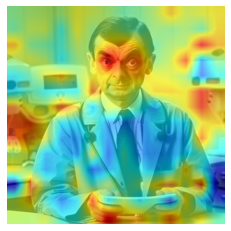

The region of: glasses


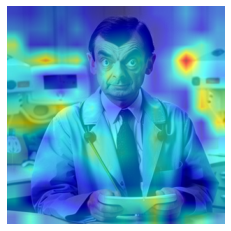

The region of: suit


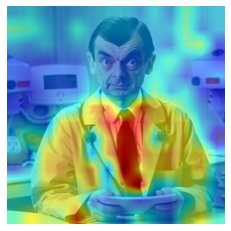

The region of: tie


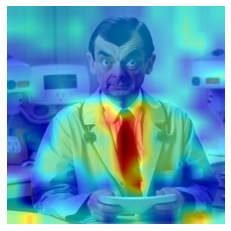

In [12]:
pil_img = Image.open("alignment-example.jpg")
am,as0=alignment_map(pil_img,noun_parts,red=[""],draw=True)
_,as1=alignment_map(pil_img,filtered_parts,red=[""],draw=False)

In [30]:
for num in range(len(filtered_parts)):
    print('The score of ['+noun_parts[num]+' | '+filtered_parts[num]+'] is [%.4f | %.4f]'%(as0[num],as1[num]))

The score of [Beans | Mr. Beans wearing] is [0.6572 | 0.9285]
The score of [glasses | sun glasses] is [0.4550 | 0.4006]
The score of [suit | blue doctor suit] is [0.5490 | 0.8180]
The score of [tie | stripe tie] is [0.5849 | 0.5791]


# Draw Step-1

In [37]:
from diffusers import AutoPipelineForInpainting
from diffusers.utils import load_image
device = "cuda"
model_path = "Your path of SDXL inpainting"

pipe = AutoPipelineForInpainting.from_pretrained(model_path, torch_dtype=torch.float16, variant="fp16").to(device)

A matching Triton is not available, some optimizations will not be enabled.
Error caught was: No module named 'triton'


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 37000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


Perceptual map. Larger bound will modify more region.


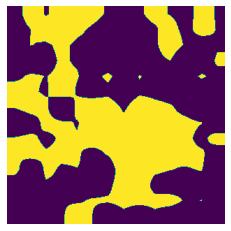

In [38]:
perceptual_map=pm*255
perceptual_bound=100
perceptual_region=np.where(perceptual_map<perceptual_bound, 255, 0)
print('Perceptual map. Larger bound will modify more region.')
plt.imshow(perceptual_region)
plt.axis('off')
plt.show()

In [39]:
alignment_map=np.zeros(np.shape(am[0]))
for num in range(len(noun_parts)):    
    wrong_ind=[]
    if as0[num]<0.5:
        par=filtered_parts.index(phrase_to_parent_dictionary[filtered_parts[num]])
        print('Map weight added on prompt index '+str(par)+ ' [' + filtered_parts[par]+']')
        print('Text weight added on prompt index '+str(num)+ ' [' + filtered_parts[num]+']')
#        alignment_map=alignment_map*am[par]/128
        alignment_map=np.maximum(alignment_map,am[par])
        wrong_ind.append(num)
    else:
        if as0[num]>as1[num]:
#            alignment_map=alignment_map*am[num]/128
            alignment_map=np.maximum(alignment_map,am[num])
            print('Map weight added on prompt index '+str(num)+ ' [' + filtered_parts[num]+']')
            print('Text weight added on prompt index '+str(num)+ ' [' + filtered_parts[num]+']')
            wrong_ind.append(num)
# alignment_map

Map weight added on prompt index 0 [Mr. Beans wearing]
Text weight added on prompt index 1 [sun glasses]
Map weight added on prompt index 3 [stripe tie]
Text weight added on prompt index 3 [stripe tie]


Visualization example of adding region of word (0,3) together:


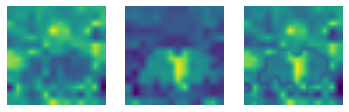

In [40]:
print('Visualization example of adding region of word (0,3) together:')
plt.subplot(1,3,1)
plt.imshow(am[0])
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(am[3])
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(alignment_map)
plt.axis('off')
plt.show()

Alignment map. Smaller bound will modify more region.


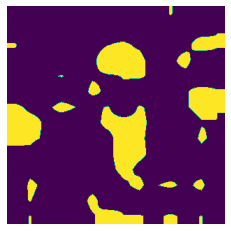

In [41]:
alignment_bound=170
alignment_region=np.where(alignment_map>alignment_bound, 255, 0)
print('Alignment map. Smaller bound will modify more region.')
plt.imshow(alignment_region)
plt.axis('off')
plt.show() 

Merge perceptual and alignment map. Yellow region will be modified.


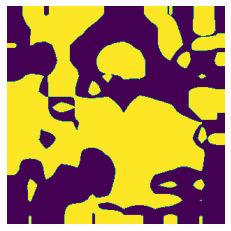

In [42]:
final_map=np.maximum(alignment_region,perceptual_region)
print('Merge perceptual and alignment map. Yellow region will be modified.')
plt.imshow(final_map)
plt.axis('off')
plt.show() 

  0%|          | 0/36 [00:00<?, ?it/s]

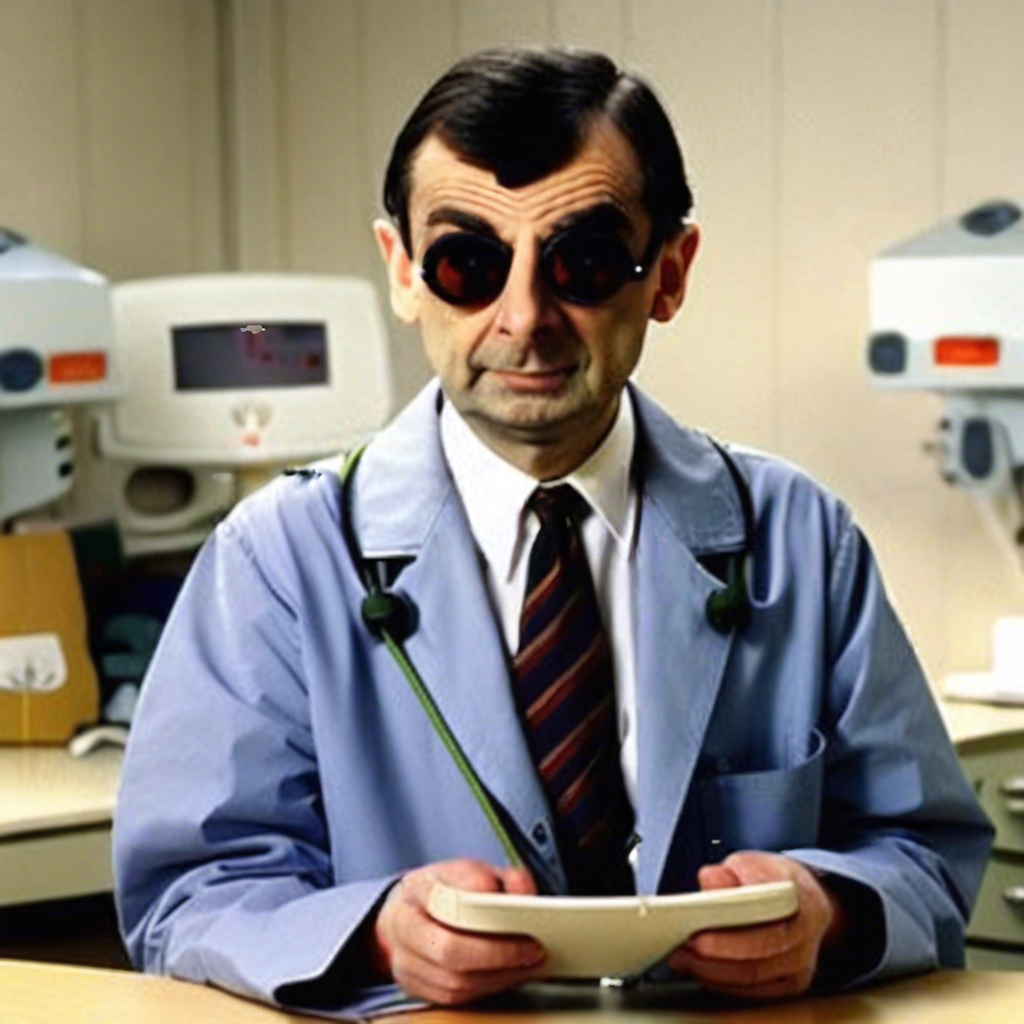

In [43]:
AIGC_txt=query
img=pil_img

## Smaller 
width=int(img.size[0]/max(img.size)*32)*32
height=int(img.size[1]/max(img.size)*32)*32
output = pipe(
    prompt=AIGC_txt+', high quality'+', hyper detail',
    image=img.resize((width,height)),
    mask_image=Image.fromarray(alignment_region.astype('uint8')).resize((width,height)),
    strength=0.9,
    num_inference_steps=40,
    num_images_per_prompt=1,
    ).images[0]
output

In [47]:
output.save('step-1.jpg')

# Draw Step-2

In [54]:
del pipe
torch.cuda.empty_cache()
print('Delete step 1 model, type your path of PASD')

Delete step 1 model, type your path of PASD


In [69]:
print('Execute step-2, please install PASD in this dictionary')
!cd PASD
!python test_pasd.py --image_path ../step-1.jpg --prompt "Mr. Beans wearing sun glasses with blue doctor suit and stripe tie" --output_dir ../

Execute step-2, please install PASD in this dictionary


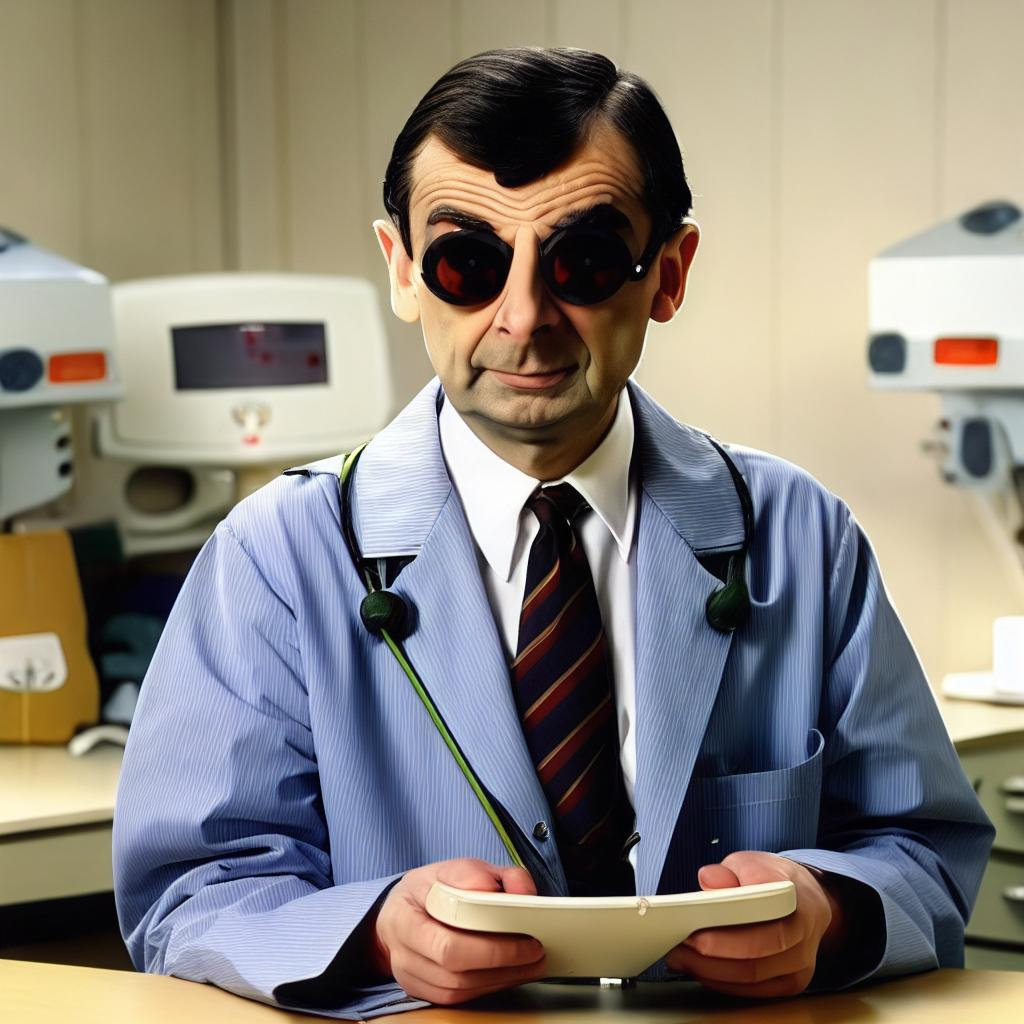

In [70]:
Image.open('step-2.jpg')